# Linear Regression Project: Predicting House Prices

In this notebook, you will build a **Linear Regression** model to predict house prices using the `USA_Housing.csv` dataset.

The goal is to complete the full machine learning workflow by yourself:

1. Import libraries
2. Load and inspect the dataset
3. Perform exploratory data analysis
4. Prepare features and target
5. Split the data into training and testing sets
6. Train a Linear Regression model
7. Make predictions
8. Evaluate the model
9. Interpret the results

### Dataset columns

- `Avg. Area Income`: Average income of people living in the area
- `Avg. Area House Age`: Average age of houses in the area
- `Avg. Area Number of Rooms`: Average number of rooms in houses in the area
- `Avg. Area Number of Bedrooms`: Average number of bedrooms in houses in the area
- `Area Population`: Population of the area
- `Price`: House price
- `Address`: Address of the house

## 1. Import Libraries

Import the libraries needed for:

- Data analysis
- Data visualization
- Train/test split
- Linear Regression
- Regression evaluation metrics

In [14]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

# machine learning
import sklearn.linear_model as lm
import sklearn.metrics as metrics


## 2. Load the Dataset

Load the `USA_Housing.csv` file into a DataFrame named `df`.

The CSV file should be in the same folder as this notebook.

In [2]:
df = pd.read_csv('USA_Housing.csv')

## 3. First Look at the Data

Display the first rows of the dataset.

In [3]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


Check the number of rows and columns.

In [4]:
df.shape

(5000, 7)

Display the column names.

In [5]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='str')

Check basic dataset information such as column types and non-null values.

In [ ]:
# Write your code here

Generate descriptive statistics for the numeric columns.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB


## 4. Check Missing Values and Duplicates

Check if the dataset contains missing values.

In [8]:
# Write your code here

df.isna().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

Check if the dataset contains duplicated rows.

In [9]:
df.duplicated().sum()

np.int64(0)

Remove duplicated rows if they exist.

In [ ]:
# Write your code here

### Cleaning Decision

Before modeling, decide which column should not be used as a numeric input feature and explain why.

In [11]:
# Write your explanation as a comment here

df.head()

df.drop("Address", axis=1, inplace=True)

In [12]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


## 5. Exploratory Data Analysis - EDA

Use visualizations to better understand the dataset.

### 5.1 Price Distribution

Create a histogram with KDE to visualize the distribution of house prices.

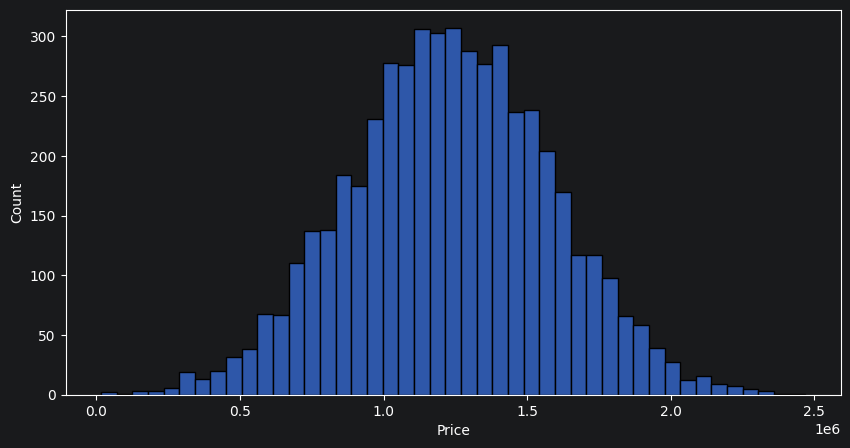

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Price')
plt.show()


### 5.2 Pairplot

Create a pairplot to compare relationships between numeric columns.

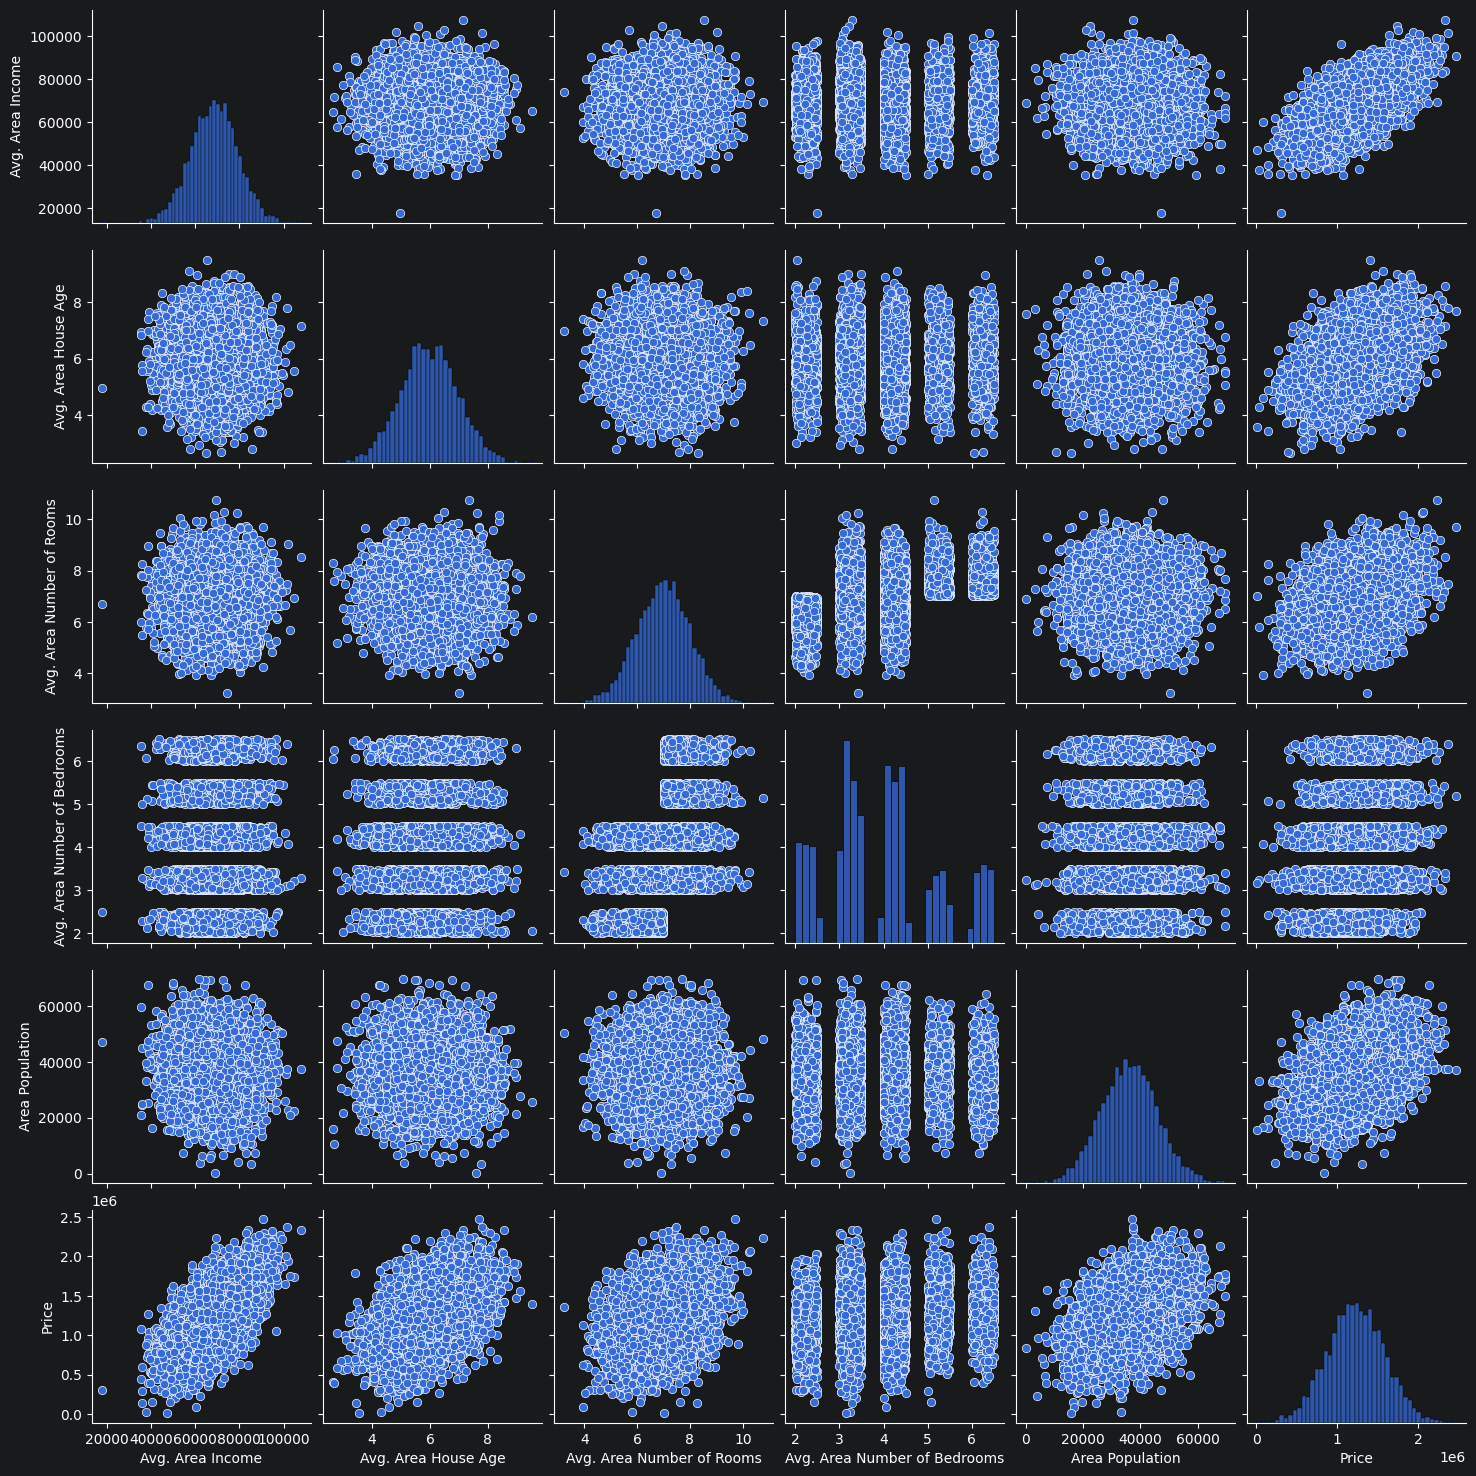

In [17]:
sns.pairplot(df)

### 5.3 Correlation Heatmap

Create a heatmap showing correlations between numeric columns.

Then identify which features seem most related to `Price`.

<Axes: >

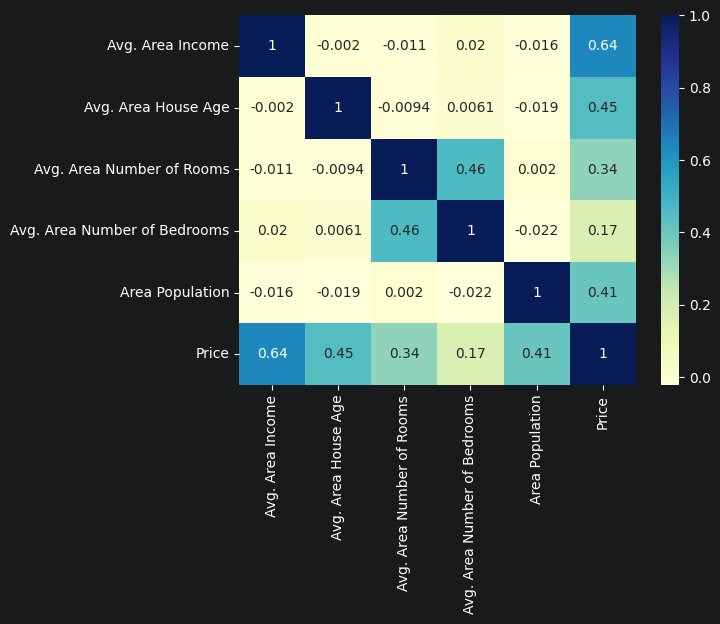

In [20]:
sns.heatmap(data = df.corr(numeric_only=True), annot=True, cmap="YlGnBu")

### 5.4 Price vs Important Features

Create scatter plots comparing `Price` with important numeric features.

In [24]:
df.columns = ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'no_bed_rooms', 'Area Population', 'Price']


<Axes: xlabel='Avg. Area Income', ylabel='Price'>

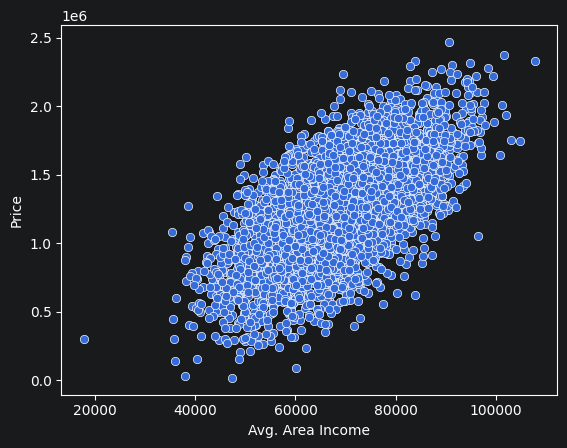

In [21]:
sns.scatterplot(data=df, x= 'Avg. Area Income', y='Price')

<Axes: xlabel='no_bed_rooms', ylabel='Price'>

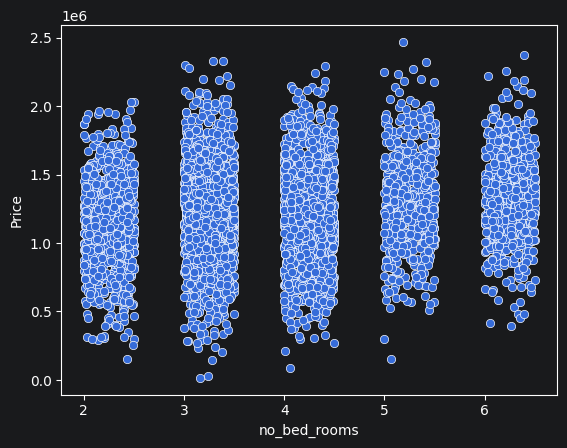

In [25]:
sns.scatterplot(data=df, x= 'no_bed_rooms', y='Price')

## 6. Prepare Features and Target

Create:

- `X`: input features
- `y`: target column

Use `Price` as the target.

Do not include raw text columns in `X`.

In [27]:
X = df.drop("Price", axis=1)   #features

y = df['Price']                #target

Display the first rows of `X`.

In [28]:
# Write your code here
X.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,no_bed_rooms,Area Population
0,79545.458574,5.682861,7.009188,4.09,23086.800503
1,79248.642455,6.002900,6.730821,3.09,40173.072174
2,61287.067179,5.865890,8.512727,5.13,36882.159400
3,63345.240046,7.188236,5.586729,3.26,34310.242831
4,59982.197226,5.040555,7.839388,4.23,26354.109472


Display the first rows of `y`.

In [29]:
y

0       1.059034e+06
1       1.505891e+06
2       1.058988e+06
3       1.260617e+06
4       6.309435e+05
            ...     
4995    1.060194e+06
4996    1.482618e+06
4997    1.030730e+06
4998    1.198657e+06
4999    1.298950e+06
Name: Price, Length: 5000, dtype: float64

## 7. Train/Test Split

Split the data into training and testing sets.

Use:

- 70% training data
- 30% testing data
- `random_state=101`

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.3, random_state=101)


Print the shapes of `X_train`, `X_test`, `y_train`, and `y_test`.

In [33]:
X_train.shape

(3500, 5)

In [34]:
X_test

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,no_bed_rooms,Area Population
1718,66774.995817,5.717143,7.795215,4.32,36788.980327
2511,62184.539375,4.925758,7.427689,6.22,26008.309124
345,73643.057298,6.766853,8.337085,3.34,43152.139577
2521,61909.041438,6.228343,6.593138,4.29,28953.925377
54,72942.705059,4.786222,7.319886,6.41,24377.909049
...,...,...,...,...,...
3412,57311.554130,5.259292,7.816295,4.18,21976.646116
4020,76856.303857,5.507289,6.465832,4.38,29382.089788
4635,59861.632185,8.096904,6.262021,2.12,45919.176414
1700,59030.172550,6.157625,5.300798,2.26,22803.099711


In [35]:
y_test

1718    1.251689e+06
2511    8.730483e+05
345     1.696978e+06
2521    1.063964e+06
54      9.487883e+05
            ...     
3412    7.043759e+05
4020    1.254938e+06
4635    1.434324e+06
1700    5.340775e+05
790     1.427202e+06
Name: Price, Length: 1500, dtype: float64

## 8. Create and Train the Linear Regression Model

Create a Linear Regression model object.

In [36]:
lr = lm.LinearRegression()

In [38]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Train the model using the training data.

In [ ]:
# Write your code here

## 9. Make Predictions

Use the trained model to predict house prices for `X_test`.

In [42]:
predicted = lr.predict(X_test)

Display the first 10 predicted values.

In [44]:
predicted

array([1258934.89505291,  822694.63411042, 1742214.39530122, ...,
       1452640.96473339,  645797.13026312, 1364943.76221893],
      shape=(1500,))

## 10. Compare Actual and Predicted Prices

Create a DataFrame that contains:

- Actual Price
- Predicted Price
- Difference
- Absolute Error

In [45]:
pd.DataFrame(
    {
        "Actual Price": y_test,
        "Predicted Price": predicted,
        "Diff": y_test - predicted,
        "Abs Diff": abs(y_test - predicted)

    }
)

,Actual Price,Predicted Price,Diff,Abs Diff
1718,1.251689e+06,1.258935e+06,-7246.279350,7246.279350
2511,8.730483e+05,8.226946e+05,50353.685532,50353.685532
345,1.696978e+06,1.742214e+06,-45236.732469,45236.732469
2521,1.063964e+06,9.729370e+05,91027.283222,91027.283222
54,9.487883e+05,9.945460e+05,-45757.715868,45757.715868
...,...,...,...,...
3412,7.043759e+05,7.555650e+05,-51189.091431,51189.091431
4020,1.254938e+06,1.168110e+06,86828.018619,86828.018619
4635,1.434324e+06,1.452641e+06,-18317.139577,18317.139577
1700,5.340775e+05,6.457971e+05,-111719.674787,111719.674787


### Actual vs Predicted Scatter Plot

Create a scatter plot comparing actual prices with predicted prices.

A better model should have points closer to a diagonal pattern.

<Axes: xlabel='Price'>

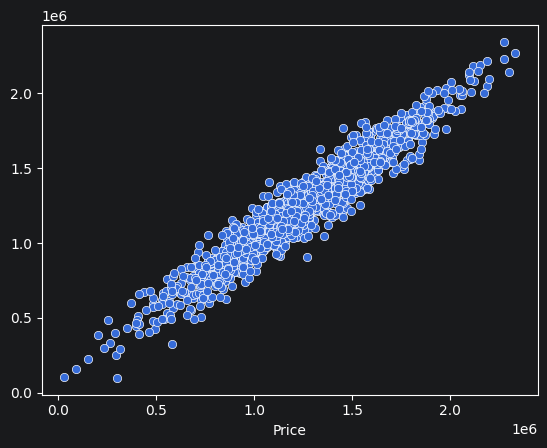

In [46]:
sns.scatterplot(x=y_test, y= predicted)

### Residuals

Residuals are prediction errors:

$$Residual = Actual\ Price - Predicted\ Price$$

Calculate residuals and visualize their distribution.

In [47]:
residual = y_test - predicted

<Axes: xlabel='Price', ylabel='Count'>

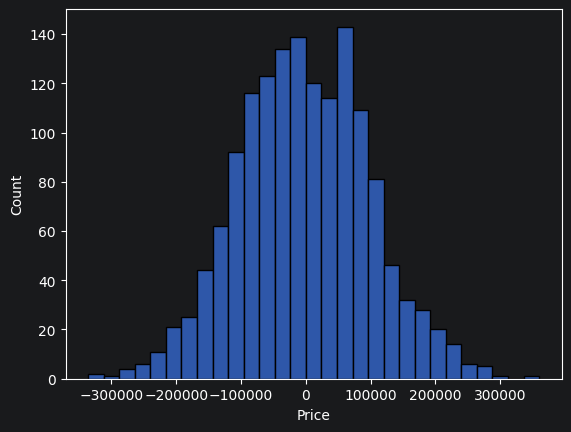

In [48]:
sns.histplot(data=residual)

## 11. Model Coefficients

Print the model intercept.

In [49]:
# Write your code here
lr.intercept_

np.float64(-2641372.6673014304)

Create a DataFrame showing each feature and its coefficient.

In [50]:
# Write your code here

pd.DataFrame(
    {
        "Feature": X.columns,
        "Coefficient": lr.coef_,
    }
)

,Feature,Coefficient
0,Avg. Area Income,21.617635
1,Avg. Area House Age,165221.119872
2,Avg. Area Number of Rooms,121405.376596
3,no_bed_rooms,1318.718783
4,Area Population,15.225196


### Coefficient Interpretation

Choose one coefficient and explain what it means in simple words.

In [ ]:
# Write your explanation as a comment here

## 12. Regression Evaluation Metrics

Calculate and print these metrics:

- MAE
- MSE
- RMSE
- R² Score

In [51]:
mae = metrics.mean_absolute_error(y_test, predicted)
mse = metrics.mean_squared_error(y_test, predicted)
rmse = metrics.root_mean_squared_error(y_test, predicted)
r2 = metrics.r2_score(y_test, predicted)

In [55]:
y_test.mean()

np.float64(1241131.5741862468)

In [52]:
print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R2: ", r2)

MAE:  81257.55795855941
MSE:  10169125565.897606
RMSE:  100842.08231635048
R2:  0.9185060945363622


Calculate the training score and testing score.

In [ ]:
# Write your code here

## 13. Predict Price for One New House

Create one new sample house as a DataFrame.

The new DataFrame must have the same feature columns as `X`.

In [56]:
X_train.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'no_bed_rooms', 'Area Population'],
      dtype='str')

In [61]:
new_house = pd.DataFrame(
    {
        "Avg. Area Income": [100000],
        "Avg. Area House Age":[ 5],
        "Avg. Area Number of Rooms" : [7],
        "no_bed_rooms" : [2],
        "Area Population" : [40000]

    }
)

In [59]:
new_house

,Area Income,Area House Age,Area Number of Rooms,no_bed_rooms,Area Population
0,100000,5,7,2,40000


Use the trained model to predict the price of the new house.

In [62]:
# Write your code here
lr.predict(new_house)

array([1807979.32515042])

## 14. Final Conclusion

Write a short conclusion answering these questions:

1. Which features seem most related to house price?
2. Did the model perform well?
3. What do MAE, RMSE, and R² tell us about the model?
4. What could be improved in a future version of the model?

In [ ]:
# Write your conclusion here as comments or markdown